## Question 2
### Q2(a) Bloom Filter implementation


1. **False Positive Rate (FPR)**:
   - The probability that a non-present item is incorrectly identified as present.
   - Formula:
     $$ FPR \approx \left(1 - e^{-\frac{k \cdot n}{m}}\right)^k $$
     where:
     - \( m \): Size of the bit array.
     - \( k \): Number of hash functions.
     - \( n \): Number of items inserted (number of unique `StockCode` values).

2. **Optimal Number of Hash Functions**:
   - Minimizes FPR for given \( m \) and \( n \).
   - Formula:
     $$ k_{opt} = \frac{m}{n} \cdot \ln(2) \approx 0.693 \cdot \frac{m}{n} $$
     Example: For \( m = 10000 \), \( n \approx 4000 \), 
     $$ k_{opt} \approx{0.693} \cdot \frac{10000}{4000} = 0.693 \cdot 2.5 \approx 1.7325 $$
     Thus, \( k ~ 4  \) or \( k  ~ 5 \) is optimal, though \( k = 7 \) is reasonable for practical purposes.

3. **Sensitivity**:
   - The probability that a present item is correctly identified (true positive rate).
   - Formula:
     $$ \text{Sensitivity} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} $$
     $$ \text{Sensitivity} = 1 $$
     Since Bloom Filters have no false negatives, all present items are correctly identified.

4. **Experimental FPR Calculation**:
   - Empirical FPR is calculated as:
     $$ \text{FPR} = \frac{\text{Number of false positives}}{\text{Number of non-present items tested}} $$
     where false positives are non-present items incorrectly identified as present.

In [39]:
import pandas as pd
import numpy as np
import random
import hashlib
import matplotlib.pyplot as plt

In [40]:
class BloomFilter:
    def __init__(self, size, hashfuncCnt):
        self.size = int(size)            ## M : Size of bit array
        self.hashfuncCnt = hashfuncCnt ## K : Number of hash functions 
        self.bitArray = [0] * self.size

    def addElement(self, element):
        kHash = self.hashFunction(element, seed=42)
        for hash in kHash:
            self.bitArray[hash] = 1

    def existCheck(self, element):
        kHash = self.hashFunction(element, seed=42)
        for hash in kHash:
            if self.bitArray[hash] == 0:
                return False
        return True

    def hashFunction(self, element, seed):
        kHash = []
        for i in range(self.hashfuncCnt):
            hash = (hashlib.md5((str(element) + str(seed) + str(i)).encode()).hexdigest())
            kHash.append(int(hash, 16) % self.size)
        return kHash

In [41]:
retailDf = pd.read_csv('online-retail.csv')
uniqueStkCodes = retailDf['StockCode'].unique().tolist()
present_set = set(uniqueStkCodes)
n = len(uniqueStkCodes)
print("UNIQUE SEQUENCES : ",n)


UNIQUE SEQUENCES :  4070


Using default m = 40700.0, default k = 6 (calculated optimal for m,n)
Generated test sets of present and not-present items.

--- Starting Bloom Filter Experiments (Part a) ---

Sensitivity (True Positive Rate) Check:
Items tested: 1000
Items found: 1000
Sensitivity: 1.0
Validation successful: Sensitivity is 1, as expected.

Running Experiment: FPR vs. m


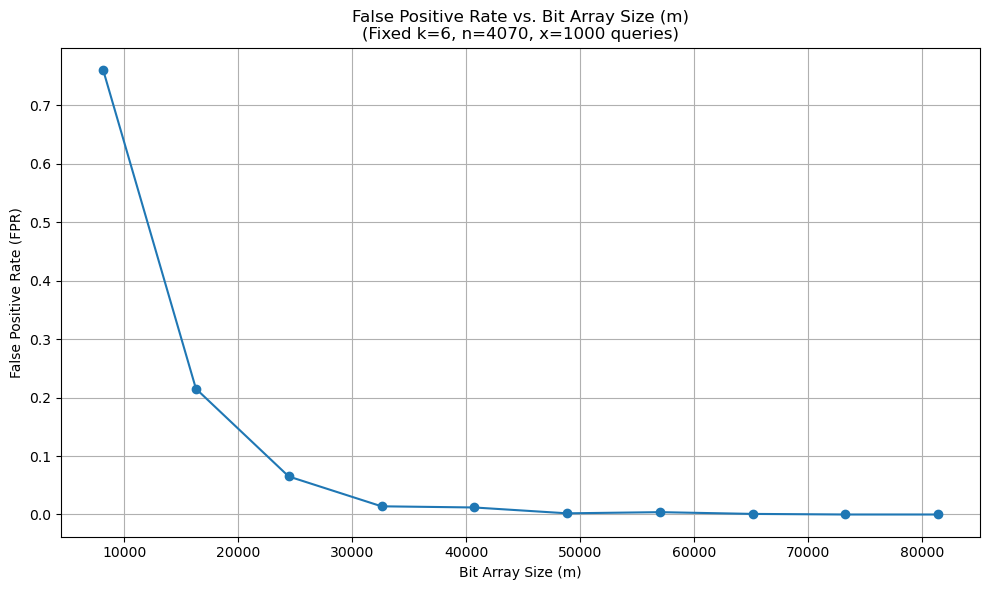


Running Experiment: FPR vs. k


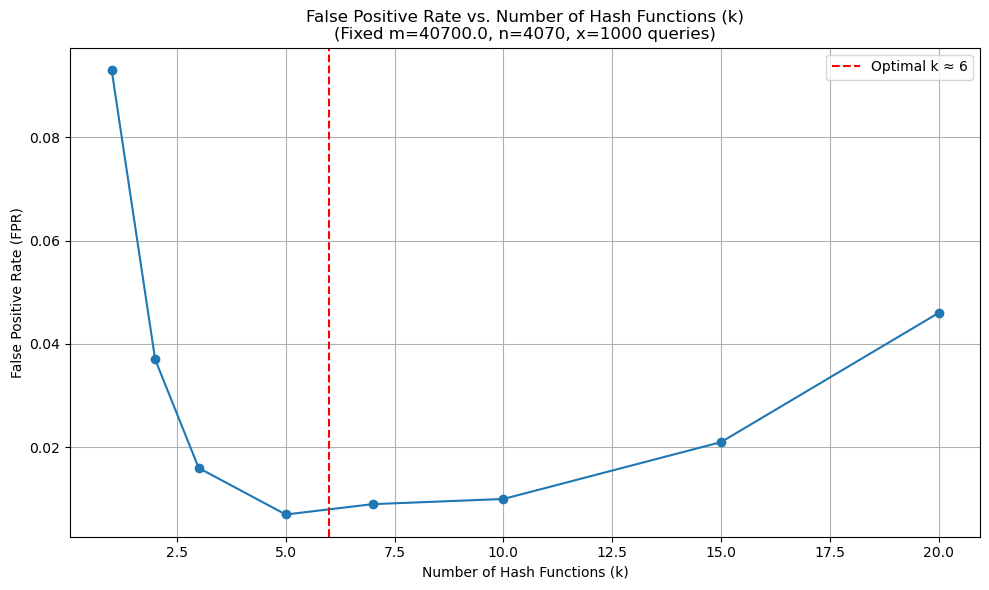


Running Experiment: FPR vs. x


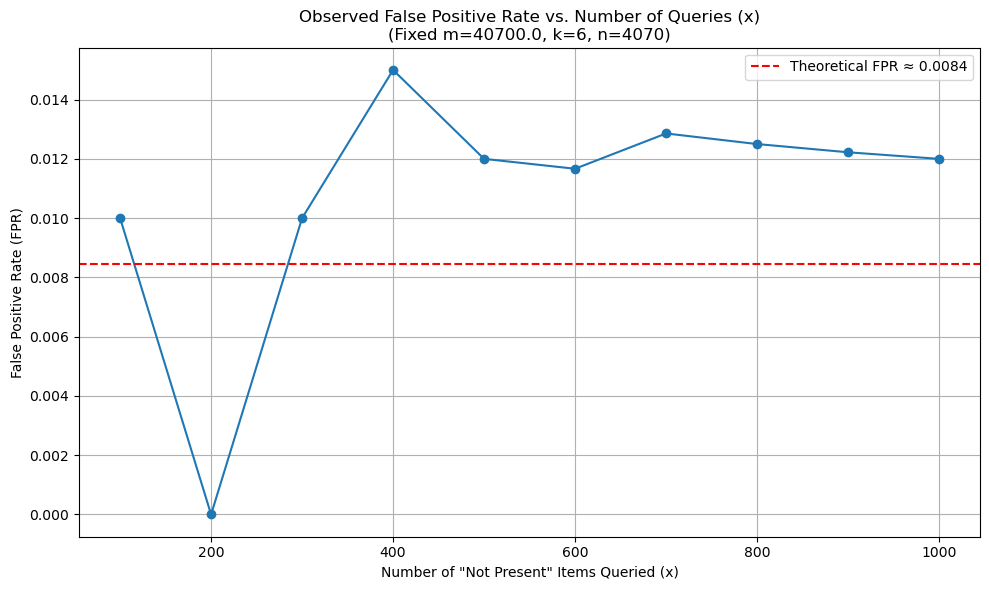

In [42]:
XCNT_VAL = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
RANDOM_PRESENT_VALUES_MAP = {}
RANDOM_NOT_PRESENT_VALUES_MAP = {}

#default parameters for experiments
DEFAULT_M = 40700.      # FOR BETTER CALCULATION , USED THE MULTIPLE OF UNIQUE ITEMS
optimal_k = int((DEFAULT_M / n) * np.log(2))

DEFAULT_K = max(1, optimal_k) # Use optimal k, at least 1
print(f"Using default m = {DEFAULT_M}, default k = {DEFAULT_K} (calculated optimal for m,n)")

# 1. Generate lists of items KNOWN to be present
for i in XCNT_VAL:
    RANDOM_PRESENT_VALUES_MAP[i] = random.sample(uniqueStkCodes, k=i)

# 2. Generate lists of items KNOWN to be NOT present
not_present_items = []
i = 0
while len(not_present_items) < max(XCNT_VAL):
    # Generate random strings
    item = f"KABOOM1234-{i}" 
    if item not in present_set:
        not_present_items.append(item)
    i += 1

for j in XCNT_VAL:
    RANDOM_NOT_PRESENT_VALUES_MAP[j] = random.sample(not_present_items, k=j)

print("Generated test sets of present and not-present items.")

# --- Part (a) Experiment 1: Validate Sensitivity (True Positive Rate) ---

print("\n--- Starting Bloom Filter Experiments (Part a) ---")
bf_sensitivity = BloomFilter(DEFAULT_M, DEFAULT_K)

# Insert all unique items
for item in uniqueStkCodes:
    bf_sensitivity.addElement(item)

# Test with 1000 known-present items
present_test_list = RANDOM_PRESENT_VALUES_MAP[1000]
true_positives = 0
for item in present_test_list:
    if bf_sensitivity.existCheck(item):
        true_positives += 1

sensitivity = true_positives / len(present_test_list)

print(f"\nSensitivity (True Positive Rate) Check:")
print(f"Items tested: {len(present_test_list)}")
print(f"Items found: {true_positives}")
print(f"Sensitivity: {sensitivity}")
if sensitivity == 1.0:
    print("Validation successful: Sensitivity is 1, as expected.")
else:
    print("Validation FAILED: Sensitivity is not 1")


# --- Part (a) Graph 1: FPR vs. m (fixed k, fixed x) ---
print("\nRunning Experiment: FPR vs. m")
# Vary m from 2*n to 20*n
m_values = [n * i for i in range(2, 21, 2)]
fpr_vs_m = []
fixed_k = DEFAULT_K
fixed_x = 1000
test_items_not_present = RANDOM_NOT_PRESENT_VALUES_MAP[fixed_x]

for m in m_values:
    bf = BloomFilter(size=m, hashfuncCnt=fixed_k)
    for item in uniqueStkCodes:
        bf.addElement(item)
    
    fp_count = 0
    for item in test_items_not_present:
        if bf.existCheck(item):
            fp_count += 1
    
    fpr = fp_count / fixed_x
    fpr_vs_m.append(fpr)

# Plotting Graph 1
plt.figure(figsize=(10, 6))
plt.plot(m_values, fpr_vs_m, marker='o', linestyle='-')
plt.title(f'False Positive Rate vs. Bit Array Size (m)\n(Fixed k={fixed_k}, n={n}, x={fixed_x} queries)')
plt.xlabel('Bit Array Size (m)')
plt.ylabel('False Positive Rate (FPR)')
plt.grid(True)
plt.tight_layout()
plt.show()



# --- Part (a) Graph 2: FPR vs. k (fixed m, fixed x) ---
print("\nRunning Experiment: FPR vs. k")
k_values = [1, 2, 3, 5, 7, 10, 15, 20]
fpr_vs_k = []
fixed_m = DEFAULT_M
fixed_x = 1000
test_items_not_present = RANDOM_NOT_PRESENT_VALUES_MAP[fixed_x]

for k in k_values:
    bf = BloomFilter(size=fixed_m, hashfuncCnt=k)
    for item in uniqueStkCodes:
        bf.addElement(item)
        
    fp_count = 0
    for item in test_items_not_present:
        if bf.existCheck(item):
            fp_count += 1
            
    fpr = fp_count / fixed_x
    fpr_vs_k.append(fpr)

# Plotting Graph 2
plt.figure(figsize=(10, 6))
plt.plot(k_values, fpr_vs_k, marker='o', linestyle='-')
plt.title(f'False Positive Rate vs. Number of Hash Functions (k)\n(Fixed m={fixed_m}, n={n}, x={fixed_x} queries)')
plt.xlabel('Number of Hash Functions (k)')
plt.ylabel('False Positive Rate (FPR)')
plt.axvline(x=DEFAULT_K, color='r', linestyle='--', label=f'Optimal k ≈ {DEFAULT_K}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Part (a) Graph 3: FPR vs. x (fixed m, fixed k) ---
print("\nRunning Experiment: FPR vs. x")
x_values = XCNT_VAL
fpr_vs_x = []
fixed_m = DEFAULT_M
fixed_k = DEFAULT_K

# Create and populate the filter ONCE
bf = BloomFilter(size=fixed_m, hashfuncCnt=fixed_k)
for item in uniqueStkCodes:
    bf.addElement(item)

for x in x_values:
    test_items_not_present = RANDOM_NOT_PRESENT_VALUES_MAP[x]
    fp_count = 0
    for item in test_items_not_present:
        if bf.existCheck(item):
            fp_count += 1
            
    fpr = fp_count / x
    fpr_vs_x.append(fpr)

# Plotting Graph 3
plt.figure(figsize=(10, 6))
plt.plot(x_values, fpr_vs_x, marker='o', linestyle='-')


# Calculate theoretical FPR for comparison
theo_fpr = (1 - (1 - 1/fixed_m)**(fixed_k * n))**fixed_k


plt.axhline(y=theo_fpr, color='r', linestyle='--', label=f'Theoretical FPR ≈ {theo_fpr:.4f}')
plt.title(f'Observed False Positive Rate vs. Number of Queries (x)\n(Fixed m={fixed_m}, k={fixed_k}, n={n})')
plt.xlabel('Number of "Not Present" Items Queried (x)')
plt.ylabel('False Positive Rate (FPR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
class DataStream:
    def __init__(self, thresh: int):
        if thresh <= 0:
            raise ValueError("Threshold must be positive")
        self.thresh = thresh
        self.freq_map = {}

    ## ACTUAL Misra-Gries Algorithm implementation
    def addElement(self, element):
        if element in self.freq_map.keys():
            self.freq_map[element] += 1
        else:
            self.freq_map[element] = 1
        if len(self.freq_map) >= self.thresh:
            keys_to_remove = []
            for key in self.freq_map.keys():
                self.freq_map[key] -= 1
                if self.freq_map[key] == 0:
                    keys_to_remove.append(key)
            for key in keys_to_remove:
                del self.freq_map[key]

    def queryEle(self, element):
        if element in self.freq_map.keys():
            return self.freq_map.get(element,0)
    
    def freqElereturn(self):
        return self.freq_map

In [44]:
dataframe = pd.read_csv('online-retail.csv')
stockCodes = dataframe['StockCode']
direct_freq_map = {}
for code in stockCodes:
    if code in direct_freq_map:
        direct_freq_map[code] += 1
    else:
        direct_freq_map[code] = 1

print("Direct frequency count of elements:")
print(len(direct_freq_map))
n = len(stockCodes)
print(f"Total items in stream: {n}")
print(f"Unique StockCodes: {len(direct_freq_map)}")

Direct frequency count of elements:
4070
Total items in stream: 541909
Unique StockCodes: 4070


   k  Accuracy (Top-50 Found)  Max. Observed Error  Theoretical Bound (N/k)
  10                     0.02                 2313                 54190.90
  25                     0.06                 2313                 21676.36
  50                     0.06                 2313                 10838.18
 100                     0.10                 2313                  5419.09
 300                     0.46                 1799                  1806.36
 700                     1.00                  712                   774.16
 900                     1.00                  521                   602.12
1000                     1.00                  452                   541.91


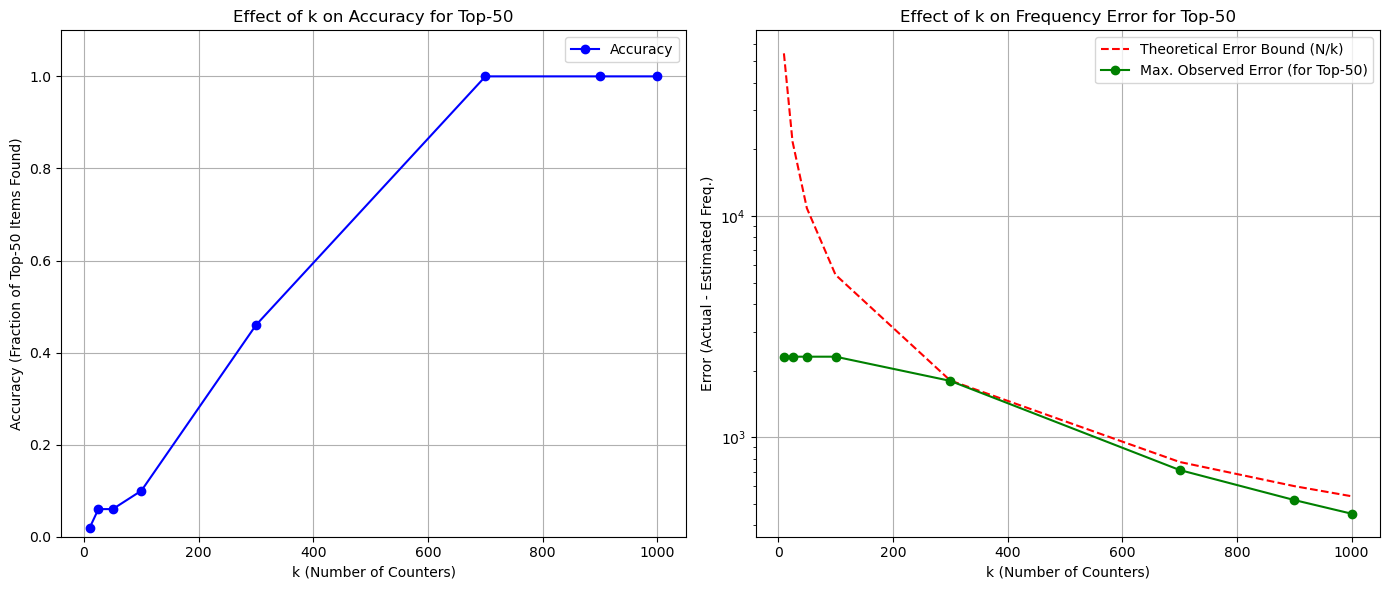

In [45]:
k_values = [10,25,50, 100, 300, 700,900, 1000]


## TOP 50 
actual_top_50 = sorted(direct_freq_map.items(), key=lambda x: x[1], reverse=True)[:50]
actual_top_50_items = {item for item, _ in actual_top_50}
n = len(stockCodes)

results = []

for k in k_values:

    # 2. Run the Misra-Gries algorithm
    misra_gries = DataStream(thresh=k)
    for code in stockCodes:
        misra_gries.addElement(code)
    
    estimated_freq_map = misra_gries.freqElereturn()
    
    # 4. Compare and Report
    
    items_found = actual_top_50_items.intersection(estimated_freq_map.keys())
    accuracy = len(items_found) / 50  # Fixed denominator to 50
    
    theoretical_error_bound = n / k
    
    # Calculate observed error *for the top-50 items*
    observed_errors = []
    for item, actual_freq in actual_top_50:
        estimated_freq = estimated_freq_map.get(item, 0)
        error = actual_freq - estimated_freq
        observed_errors.append(error)
    
    max_observed_error = np.max(observed_errors)
    
    results.append({
        'k': k,
        'Accuracy (Top-50 Found)': accuracy,
        'Max. Observed Error': max_observed_error,
        'Theoretical Bound (N/k)': theoretical_error_bound
    })


results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format="%.2f"))


plt.figure(figsize=(14, 6))

# Plot 1: k vs. Accuracy
plt.subplot(1, 2, 1)
plt.plot(results_df['k'], results_df['Accuracy (Top-50 Found)'], 'bo-', label='Accuracy')
plt.title('Effect of k on Accuracy for Top-50')
plt.xlabel('k (Number of Counters)')
plt.ylabel('Accuracy (Fraction of Top-50 Items Found)')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()

# Plot 2: k vs. Error Bounds
plt.subplot(1, 2, 2)
plt.plot(results_df['k'], results_df['Theoretical Bound (N/k)'], 'r--', label='Theoretical Error Bound (N/k)')
plt.plot(results_df['k'], results_df['Max. Observed Error'], 'go-', label='Max. Observed Error (for Top-50)')
plt.title('Effect of k on Frequency Error for Top-50')
plt.xlabel('k (Number of Counters)')
plt.ylabel('Error (Actual - Estimated Freq.)')
plt.yscale('log')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()